<a href="https://colab.research.google.com/github/marsrabin13/DI_Bootcamp/blob/colab/Week_8_Day_4_Daily_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression: Predicting University Admission from Exam Scores

**Goal:** Given two exam scores for a group of applicants, predict whether each
applicant was admitted to university (`1`) or not (`0`).

This is a classic *binary classification* problem, and logistic regression is
one of the simplest and most widely-used algorithms for it. Instead of
predicting a continuous number (like linear regression), logistic regression
predicts a probability between 0 and 1 that an example belongs to the
"positive" class (here, "admitted"), and rounds that to a final 0/1 answer.

We'll walk through these steps:
1. Load and explore the data
2. Visualize it
3. Split the data into a training set and a test set
4. Train a logistic regression model with scikit-learn
5. Make predictions on the test set and measure accuracy
6. Evaluate and interpret the results

> 💡 Tip for Colab: run each cell in order with **Shift + Enter**.


## 0. Import the libraries we'll need

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Makes plots a bit bigger and easier to read
plt.rcParams['figure.figsize'] = (7, 5)


## 1. Data Exploration

The dataset comes from Andrew Ng's Machine Learning course. It's a plain
text file (`ex2data1.txt`) where each row is one applicant, with three
comma-separated values:

1. Score on Exam 1
2. Score on Exam 2
3. Admission result: `1` = admitted, `0` = not admitted

The file has **no header row**, so we tell `pandas` the column names
ourselves.


In [5]:
url = "https://raw.githubusercontent.com/kaleko/CourseraML/refs/heads/master/ex2/data/ex2data1.txt"

# The file has no header row, so we supply our own column names.
df = pd.read_csv(url, header=None, names=["Exam1", "Exam2", "Admitted"])

print("Shape of the dataset:", df.shape)
df.head()


Shape of the dataset: (100, 3)


,Exam1,Exam2,Admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


In [6]:
# A quick statistical summary of the numeric columns
df.describe()


,Exam1,Exam2,Admitted
count,100.000000,100.000000,100.000000
mean,65.644274,66.221998,0.600000
std,19.458222,18.582783,0.492366
min,30.058822,30.603263,0.000000
25%,50.919511,48.179205,0.000000
50%,67.032988,67.682381,1.000000
75%,80.212529,79.360605,1.000000
max,99.827858,98.869436,1.000000


In [7]:
# How many students were admitted vs not admitted?
df["Admitted"].value_counts().rename({1: "Admitted", 0: "Not Admitted"})


,count
Admitted,
Admitted,60
Not Admitted,40


## 2. Visualize the Data

Before modeling anything, it's always a good idea to *look* at the data.
We'll make a scatter plot of Exam 1 score vs. Exam 2 score, and color each
point by whether that student was admitted or not. This helps us see
whether the two classes are roughly separable — which is exactly the
assumption logistic regression relies on.


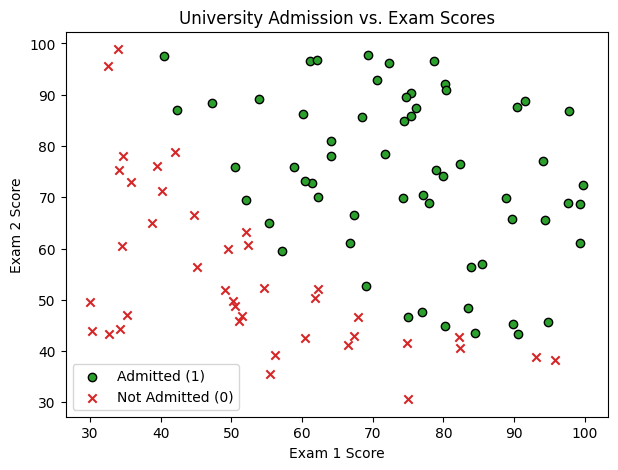

In [8]:
admitted = df[df["Admitted"] == 1]
not_admitted = df[df["Admitted"] == 0]

plt.scatter(admitted["Exam1"], admitted["Exam2"],
            c="tab:green", marker="o", label="Admitted (1)", edgecolor="k")
plt.scatter(not_admitted["Exam1"], not_admitted["Exam2"],
            c="tab:red", marker="x", label="Not Admitted (0)")

plt.xlabel("Exam 1 Score")
plt.ylabel("Exam 2 Score")
plt.title("University Admission vs. Exam Scores")
plt.legend()
plt.show()


Notice how students with higher scores on *both* exams tend to cluster in
the "admitted" group (green circles, upper right), while students with
lower scores on both exams tend to be "not admitted" (red x's, lower
left). There's a visible, roughly diagonal boundary between the two
groups — that's a good sign that a linear model like logistic regression
should work reasonably well here.


## 3. Splitting the Data: Training Set vs. Test Set

So far we've only looked at the whole dataset. Before training the model,
we're going to split it into two pieces:

- **Training set** (80% of the rows): the data the model actually learns
  from when we call `.fit()`.
- **Test set** (20% of the rows): data the model *never sees* during
  training. We hold it back so that afterward we can check how well the
  model performs on students it hasn't already "memorized."

This matters because if we trained and evaluated on the exact same rows,
a high accuracy score wouldn't tell us much — the model could just be
good at recalling data it already saw, without actually having learned
anything that generalizes to new students. Testing on held-out data gives
a much more honest measure of performance.

`train_test_split` does this for us. `test_size=0.2` means 20% of the
rows go into the test set, and `random_state=42` just makes the random
split reproducible (you'll get the same split every time you run this
cell).


In [9]:
X = df[["Exam1", "Exam2"]]
y = df["Admitted"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])


Training set size: 80
Test set size: 20


## 4. Applying Logistic Regression with scikit-learn

Now we'll build the model and train ("fit") it — but only on the
**training set**, `X_train` and `y_train`. The test set stays untouched
for now.

scikit-learn's `LogisticRegression` handles all the underlying math for
us (fitting the sigmoid function, optimizing the cost function, etc.), so
we just need to create the model and call `.fit()`.


In [10]:
# Create the logistic regression model
model = LogisticRegression()

# Train ("fit") the model, using ONLY the training data
model.fit(X_train, y_train)

print("Model coefficients (weights):", model.coef_)
print("Model intercept (bias):", model.intercept_)


Model coefficients (weights): [[0.25970232 0.22481016]]
Model intercept (bias): [-30.20000099]


**Interpreting the coefficients:** logistic regression learns a linear
combination of the inputs, `z = w1*Exam1 + w2*Exam2 + b`, and then squashes
`z` into a probability with the sigmoid function. Both coefficients above
should be positive, which makes sense: a *higher* score on either exam
increases the predicted probability of admission. The relative size of the
two coefficients tells you which exam has more influence on the
prediction, according to the model.


## 5. Making Predictions on the Test Set

With the model trained, we use `.predict()` to make predictions — this
time on `X_test`, the 20% of students the model has never seen before.
`.predict()` returns the model's final 0/1 class prediction for each row
(0 = not admitted, 1 = admitted).


In [11]:
# Predicted class labels for the test set (0 = not admitted, 1 = admitted)
y_pred = model.predict(X_test)

# Compare the model's predictions to the actual outcomes
results = pd.DataFrame({
    "Exam1": X_test["Exam1"],
    "Exam2": X_test["Exam2"],
    "Actual": y_test,
    "Predicted": y_pred
})
results


,Exam1,Exam2,Actual,Predicted
83,57.238706,59.514282,1,0
53,34.524514,60.396342,0,0
70,32.722833,43.307173,0,0
45,62.222676,52.060992,0,0
44,51.047752,45.822701,0,0
39,34.183640,75.237720,0,0
22,50.534788,48.855812,0,0
80,88.913896,69.803789,1,1
10,95.861555,38.225278,0,1
0,34.623660,78.024693,0,0


In [12]:
# Example: predict the admission outcome for a specific student
# (e.g. Exam 1 = 45, Exam 2 = 85)
sample = pd.DataFrame({"Exam1": [45], "Exam2": [85]})
sample_pred = model.predict(sample)

print(f"Predicted class: {sample_pred[0]} (1 = admitted, 0 = not admitted)")


Predicted class: 1 (1 = admitted, 0 = not admitted)


### Accuracy

Accuracy is simply the fraction of predictions the model got right,
measured here on the **test set** — data the model never trained on:

`accuracy = (number of correct predictions) / (total number of predictions)`


In [13]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.2%}")


Test accuracy: 80.00%


## 6. Model Evaluation

Accuracy alone doesn't tell the whole story, especially if the classes are
imbalanced. Two more useful tools are the **confusion matrix** (a table of
correct vs. incorrect predictions, broken down by class) and the
**classification report** (precision, recall, and F1-score per class).
Both are computed on the test set predictions, `y_pred` vs. `y_test`.


In [14]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print()
print("Rows = actual class, Columns = predicted class")
print("[[True Negatives,  False Positives]")
print(" [False Negatives, True Positives]]")


Confusion Matrix:
[[7 1]
 [3 9]]

Rows = actual class, Columns = predicted class
[[True Negatives,  False Positives]
 [False Negatives, True Positives]]


In [15]:
print(classification_report(y_test, y_pred, target_names=["Not Admitted", "Admitted"]))


              precision    recall  f1-score   support

Not Admitted       0.70      0.88      0.78         8
    Admitted       0.90      0.75      0.82        12

    accuracy                           0.80        20
   macro avg       0.80      0.81      0.80        20
weighted avg       0.82      0.80      0.80        20



- **Precision** (for a class): of everything the model *predicted* as that
  class, what fraction actually was that class?
- **Recall** (for a class): of everything that *actually was* that class,
  what fraction did the model correctly catch?
- **F1-score**: the harmonic mean of precision and recall — a single number
  balancing both.

With only 20 students in the test set, these numbers can jump around a lot
depending on exactly which students ended up in the test split — keep that
in mind when interpreting them.


### Visualizing the Decision Boundary

Because logistic regression is a *linear* classifier, the boundary it
draws between "admitted" and "not admitted" is a straight line. We can
plot it directly on top of our scatter plot from earlier. The model was
trained only on the training set, but here we show all 100 students
(training + test) so you can see how well the learned boundary fits the
whole picture.


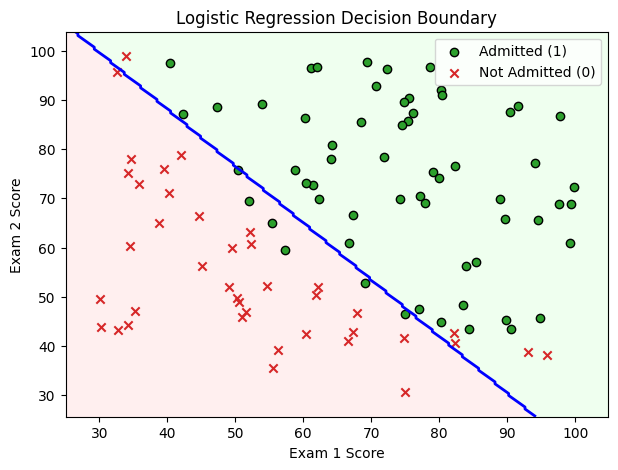

In [16]:
# Build a grid of points spanning the score ranges, then use the model's
# class predictions to draw the boundary between the "0" and "1" regions
xx, yy = np.meshgrid(
    np.linspace(df["Exam1"].min() - 5, df["Exam1"].max() + 5, 200),
    np.linspace(df["Exam2"].min() - 5, df["Exam2"].max() + 5, 200)
)
grid = pd.DataFrame({"Exam1": xx.ravel(), "Exam2": yy.ravel()})
Z = model.predict(grid).reshape(xx.shape)

plt.contour(xx, yy, Z, levels=[0.5], colors="blue", linewidths=2)
plt.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=["#ffe5e5", "#e5ffe5"], alpha=0.6)

plt.scatter(admitted["Exam1"], admitted["Exam2"],
            c="tab:green", marker="o", label="Admitted (1)", edgecolor="k")
plt.scatter(not_admitted["Exam1"], not_admitted["Exam2"],
            c="tab:red", marker="x", label="Not Admitted (0)")

plt.xlabel("Exam 1 Score")
plt.ylabel("Exam 2 Score")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()


## Conclusion & Interpretation

- We split the data into an 80% training set and a 20% test set, trained
  the model only on the training set, and measured accuracy only on the
  test set — students the model never saw while learning.
- The model learned a linear decision boundary that separates admitted
  from non-admitted students fairly well, based only on two exam scores.
- Both coefficients were positive, confirming the intuitive result that
  higher scores on either exam increase the predicted probability of
  admission.
- The test accuracy is a much more honest estimate of how the model would
  perform on a brand-new student than accuracy measured on the training
  data would be, since the model had no chance to "see" the test students
  in advance.
- The confusion matrix / classification report break that test accuracy
  down further and show whether the model makes more false positives
  (predicting "admitted" incorrectly) or false negatives (predicting
  "not admitted" incorrectly).

**A note on the test set size:** with only 100 students total, a 20%
test set is just 20 students — small enough that accuracy can swing
noticeably depending on the random split (try changing `random_state` and
re-running to see this yourself). In real projects with more data, you'd
also often use cross-validation for a more stable estimate.
